<a href="https://colab.research.google.com/github/emanuelsandez/challenge2-data-science-LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [370]:
import pandas as pd

In [371]:
import requests
import json

import requests

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
respuesta = requests.get(url)
df_datos = pd.DataFrame(respuesta)
df_datos.tail(5)



,0
29738,"b'ear"",""PaperlessBilling"":""No"",""PaymentMethod""..."
29739,"b'HOTOH"",""Churn"":""No"",""customer"":{""gender"":""Ma..."
29740,"b'eService"":""No"",""MultipleLines"":""No phone ser..."
29741,"b's"",""DeviceProtection"":""Yes"",""TechSupport"":""N..."
29742,"b'perlessBilling"":""No"",""PaymentMethod"":""Electr..."


In [372]:
df_datos = pd.json_normalize(respuesta.json())
df_datos.head(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [373]:
#Conocer la estructura del df
df_datos.shape

(7267, 21)

In [374]:
#Conocer las columnas
df_datos.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [375]:
#Conocer el tipo de dato de cada columna
df_datos.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


##Validar Nulos

In [376]:
#Verificar si existen nulos
df_datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [377]:
#VAlores únicos como clientes
df_datos['customerID'].nunique()

7267

In [378]:
#Validar falta de informacion de las otras columnas
for i in range(1,21):
  column_name = df_datos.columns[i]
  print(f'{column_name}: {df_datos[column_name].unique()}')

Churn: ['No' 'Yes' '']
customer.gender: ['Female' 'Male']
customer.SeniorCitizen: [0 1]
customer.Partner: ['Yes' 'No']
customer.Dependents: ['Yes' 'No']
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
phone.MultipleLines: ['No' 'Yes' 'No phone service']
internet.InternetService: ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
internet.OnlineBackup: ['Yes' 'No' 'No internet service']
internet.DeviceProtection: ['No' 'Yes' 'No internet service']
internet.TechSupport: ['Yes' 'No' 'No internet service']
internet.StreamingTV: ['Yes' 'No' 'No internet service']
internet.StreamingMovies: ['No' 'Yes' 'No internet service']
account.Contract: ['One year' 'Month-to-month' 'Two year']
account.PaperlessBilling: ['Yes' 'No']
account.Paymen

In [379]:
#Verificar que aquellos clientes que NO se han ido de la compañía  y posean un servicio contratado como mínimo
seleccion_1 = df_datos["Churn"]=='No'
seleccion_2 = df_datos["phone.PhoneService"]=='No'
seleccion_3 = df_datos["internet.InternetService"]=='No'
filtro_1 = df_datos[seleccion_1 & seleccion_2 & seleccion_3]
filtro_1

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


In [380]:
#Mostrar datos no son decimales en  Cargos Totales
seleccion_4 = df_datos['account.Charges.Total']== ' '
filtro_2 = df_datos[seleccion_4]
filtro_2

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [381]:
#Se mostró que los clientes nuevos tienen ' ' en cargo total son clientes nuevos. Verificar el total de clientes nuevos
clientes_nuevos= 0
for i in range(len(df_datos['customer.tenure'])):
  if df_datos['customer.tenure'][i] == 0:
    clientes_nuevos += 1
print(f'Cantidad de clientes nuevos: {clientes_nuevos}')

Cantidad de clientes nuevos: 11


In [382]:
#]Renombrar las columnas para estilizar el DataFrame
df_datos.rename(columns={'customer.gender':'gender'}, inplace=True)
df_datos.rename(columns={'customer.SeniorCitizen':'senior_citizen'}, inplace=True)
df_datos.rename(columns={'customer.Partner':'partner'}, inplace=True)
df_datos.rename(columns={'customer.Dependents':'dependents'}, inplace=True)
df_datos.rename(columns={'customer.tenure':'tenure'}, inplace=True)
df_datos.rename(columns={'phone.PhoneService':'phone_service'}, inplace=True)
df_datos.rename(columns={'phone.MultipleLines':'multiple_lines'}, inplace=True)
df_datos.rename(columns={'internet.InternetService':'internet_service'}, inplace=True)
df_datos.rename(columns={'internet.OnlineSecurity':'online_security'}, inplace=True)
df_datos.rename(columns={'internet.OnlineBackup':'online_backup'}, inplace=True)
df_datos.rename(columns={'internet.DeviceProtection':'device_protection'}, inplace=True)
df_datos.rename(columns={'internet.TechSupport':'tech_support'}, inplace=True)
df_datos.rename(columns={'internet.StreamingTV':'streaming_tv'}, inplace=True)
df_datos.rename(columns={'internet.StreamingMovies':'streaming_movies'}, inplace=True)
df_datos.rename(columns={'account.Contract':'contract'}, inplace=True)
df_datos.rename(columns={'account.PaperlessBilling':'paperless_billing'}, inplace=True)
df_datos.rename(columns={'account.PaymentMethod':'payment_method'}, inplace=True)
df_datos.rename(columns={'account.Charges.Monthly':'monthly_charges'}, inplace=True)
df_datos.rename(columns={'account.Charges.Total':'total_charges'}, inplace=True)


In [383]:
df_datos.tail(5)

,customerID,Churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


Eliminar Clientes sin datos en columna total_charges

In [384]:
#Query para seleccionar los datos de tenure a borrar (clientes nuevos)
removedor_tenure = df_datos.query('tenure == 0').index

In [385]:
#Remover los datos
df_datos.drop(removedor_tenure, axis=0, inplace=True)

In [386]:
#Verificar la cantidad de filas, para comprobar que fueron removidas
df_datos.shape

(7256, 21)

Modificar tipo de dato en total_charges

In [387]:
#Modificar tipo de dato de total_charges de string a float
import numpy as np
df_datos['total_charges'] = df_datos['total_charges'].astype(np.float64)

In [388]:
#Validar cambio
df_datos['total_charges'].dtypes

dtype('float64')

Eliminar Clientes sin información

In [389]:
removedor_churn = df_datos.query("Churn == ''").index
df_datos.drop(removedor_churn, axis = 0, inplace= True)
df_datos.shape

(7032, 21)

In [390]:
df_datos["Churn"].unique()

array(['No', 'Yes'], dtype=object)

Eliminar carácteres en método de pago

In [391]:
df_datos['payment_method']=df_datos['payment_method'].str.replace('[^a-zA-Z ]','',regex=True)
df_datos['payment_method'].unique()


array(['Mailed check', 'Electronic check', 'Credit card automatic',
       'Bank transfer automatic'], dtype=object)

Anexar nueva columna cuentas_diarias

In [392]:
df_datos['cuentas_diarias'] = (df_datos['monthly_charges']/30).round(2)
df_datos['cuentas_diarias'].sample(5)

,cuentas_diarias
109,2.48
4114,2.98
5456,0.63
5912,0.68
929,3.54


Estandarizar y transformar datos

In [393]:
#Para saber si hay falta de información en alguna de las filas de las otras columnas
for i in range(7,18):
  column_name = df_datos.columns[i]
  print(f'{column_name}: {df_datos[column_name].unique()}')

phone_service: ['Yes' 'No']
multiple_lines: ['No' 'Yes' 'No phone service']
internet_service: ['DSL' 'Fiber optic' 'No']
online_security: ['No' 'Yes' 'No internet service']
online_backup: ['Yes' 'No' 'No internet service']
device_protection: ['No' 'Yes' 'No internet service']
tech_support: ['Yes' 'No' 'No internet service']
streaming_tv: ['Yes' 'No' 'No internet service']
streaming_movies: ['No' 'Yes' 'No internet service']
contract: ['One year' 'Month-to-month' 'Two year']
paperless_billing: ['Yes' 'No']


In [394]:
#Verificar columnas que tienen como datos backup, protección, etc.. efectivamente no tengan servicio telefónico o de internet
seleccion_5 = df_datos['phone_service'] == 1
seleccion_6 = df_datos['multiple_lines'] == 'No phone service'
filtro_3 = df_datos[seleccion_5 & seleccion_6]

seleccion_7 = (df_datos['internet_service'] == 'DSL') | (df_datos['internet_service'] == 'Fiber optic')
seleccion_8 = df_datos['online_security'] == 'No internet service'
seleccion_9 = df_datos['online_backup'] == 'No internet service'
seleccion_10 = df_datos['device_protection'] == 'No internet service'
seleccion_11 = df_datos['tech_support'] == 'No internet service'
seleccion_12 = df_datos['streaming_tv'] == 'No internet service'
seleccion_13 = df_datos['streaming_movies'] == 'No internet service'

filtro_4 = df_datos[seleccion_7 & seleccion_8]
filtro_5 = df_datos[seleccion_7 & seleccion_9]
filtro_6 = df_datos[seleccion_7 & seleccion_10]
filtro_7 = df_datos[seleccion_7 & seleccion_11]
filtro_8 = df_datos[seleccion_7 & seleccion_12]
filtro_9 = df_datos[seleccion_7 & seleccion_13]

print(f'Información del filtro 3: ',filtro_3.shape)
print(f'Información del filtro 4: ',filtro_4.shape)
print(f'Información del filtro 5: ',filtro_5.shape)
print(f'Información del filtro 6: ',filtro_6.shape)
print(f'Información del filtro 7: ',filtro_7.shape)
print(f'Información del filtro 8: ',filtro_8.shape)
print(f'Información del filtro 9: ',filtro_9.shape)

Información del filtro 3:  (0, 22)
Información del filtro 4:  (0, 22)
Información del filtro 5:  (0, 22)
Información del filtro 6:  (0, 22)
Información del filtro 7:  (0, 22)
Información del filtro 8:  (0, 22)
Información del filtro 9:  (0, 22)


In [395]:
df_datos['Churn'] = df_datos['Churn'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
df_datos['partner'] = df_datos['partner'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
df_datos['dependents'] = df_datos['dependents'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
df_datos['phone_service'] = df_datos['phone_service'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
df_datos['multiple_lines'] = df_datos['multiple_lines'].replace({'Yes':1, 'No':0, 'No phone service':0}).infer_objects(copy=False)
df_datos['online_security'] = df_datos['online_security'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['online_backup'] = df_datos['online_backup'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['device_protection'] = df_datos['device_protection'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['tech_support'] = df_datos['tech_support'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['streaming_tv'] = df_datos['streaming_tv'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['streaming_movies'] = df_datos['streaming_movies'].replace({'Yes':1, 'No':0, 'No internet service':0}).infer_objects(copy=False)
df_datos['paperless_billing'] = df_datos['paperless_billing'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
df_datos.head(5)

/tmp/ipykernel_180/4223257150.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_datos['Churn'] = df_datos['Churn'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
/tmp/ipykernel_180/4223257150.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_datos['partner'] = df_datos['partner'].replace({'Yes':1, 'No':0}).infer_objects(copy=False)
/tmp/ipykernel_180/4223257150.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `r

,customerID,Churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [396]:
df_datos.dtypes

,0
customerID,object
Churn,int64
gender,object
senior_citizen,int64
partner,int64
dependents,int64
tenure,int64
phone_service,int64
multiple_lines,int64
internet_service,object


#📊 Carga y análisis

In [397]:
#Análisis descriptivo
descripcion = df_datos.describe().round(2)
descripcion = descripcion.T
descripcion

,count,mean,std,min,25%,50%,75%,max
Churn,7032.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
senior_citizen,7032.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
partner,7032.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
dependents,7032.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7032.0,32.42,24.55,1.00,9.00,29.00,55.00,72.00
phone_service,7032.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
multiple_lines,7032.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
online_security,7032.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
online_backup,7032.0,0.34,0.48,0.00,0.00,0.00,1.00,1.00
device_protection,7032.0,0.34,0.48,0.00,0.00,0.00,1.00,1.00


In [398]:
#Distribución de la evasión
total_clientes = len(df_datos['Churn'])
total_sefue = df_datos['Churn'].sum()
total_no_sefue = total_clientes - total_sefue

condicion_clientes = ['Total clientes','Abandonaron','Permanecieron']
condicion_cantidad = [total_clientes, total_sefue, total_no_sefue]

churn_dict = {'Condición clientes':condicion_clientes, 'Cantidad':condicion_cantidad}
churn_df = pd.DataFrame(churn_dict)
churn_df


,Condición clientes,Cantidad
0,Total clientes,7032
1,Abandonaron,1869
2,Permanecieron,5163


In [399]:
porcentaje_abandono = round(total_sefue/total_clientes * 100, 1)
porcentaje_permanencia = round(total_no_sefue/total_clientes * 100, 1)

In [400]:
import matplotlib.pyplot as plt

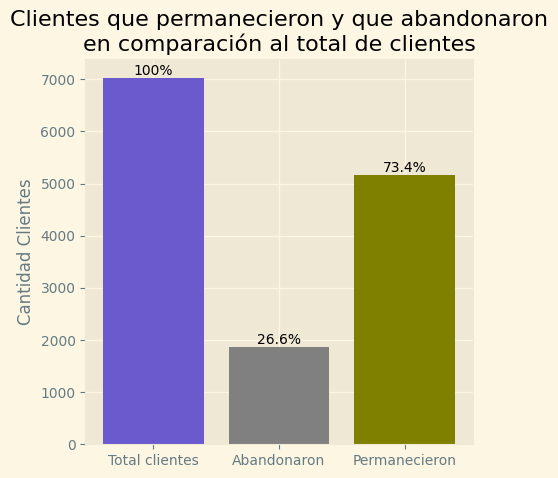

In [401]:
colores_churn = ['slateblue','gray','olive']
with plt.style.context('Solarize_Light2'):
  fig1, ax = plt.subplots(figsize=(5,5))

  ax.bar(churn_df['Condición clientes'], churn_df['Cantidad'], color = colores_churn)
  ax.set_title('Clientes que permanecieron y que abandonaron\nen comparación al total de clientes',
             loc='center',fontsize=16)
  ax.set_ylabel('Cantidad Clientes')
  ax.text(0, churn_df['Cantidad'][0],'100%', ha='center', va='bottom')
  ax.text(1, churn_df['Cantidad'][1],f'{porcentaje_abandono}%', ha='center', va='bottom')
  ax.text(2, churn_df['Cantidad'][2],f'{porcentaje_permanencia}%', ha='center', va='bottom')
  ax.grid(linewidth=1, axis='y')
  plt.show()

In [402]:
#Evasión por variables categoricas
evadidos = df_datos.query('Churn == 1')
evadidos

,customerID,Churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.80
18,0022-TCJCI,1,Male,1,0,0,45,1,0,DSL,...,1,0,0,1,One year,0,Credit card automatic,62.70,2791.50,2.09
19,0023-HGHWL,1,Male,1,0,0,1,0,0,DSL,...,0,0,0,0,Month-to-month,1,Electronic check,25.10,25.10,0.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7243,9961-JBNMK,1,Male,1,0,0,21,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Bank transfer automatic,96.80,2030.30,3.23
7246,9965-YOKZB,1,Male,1,0,0,9,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,83.85,790.15,2.80
7260,9985-MWVIX,1,Female,0,0,0,1,1,0,Fiber optic,...,0,0,0,0,Month-to-month,1,Mailed check,70.15,70.15,2.34
7261,9986-BONCE,1,Female,0,0,0,4,1,0,No,...,0,0,0,0,Month-to-month,0,Bank transfer automatic,20.95,85.50,0.70


In [403]:
total_clientes_evadidos = len(evadidos['Churn'])
print(f'El total de clientes evadidos: ',total_clientes_evadidos)

El total de clientes evadidos:  1869


In [404]:
#Diferenciar por género
gender_counts = evadidos['gender'].value_counts()

mujeres = gender_counts.get('Female', 0)
hombres = gender_counts.get('Male', 0)

genero = ['Mujeres', 'Hombres']
cantidad = [mujeres, hombres]

genero_dict = {'Género':genero, 'Cantidad':cantidad}
df_genero = pd.DataFrame(genero_dict)
df_genero['Id']= df_genero.index + 1
df_genero.set_index('Id', inplace = True)
df_genero

,Género,Cantidad
Id,,
1,Mujeres,939
2,Hombres,930


In [405]:
#Rango etareo
senior = evadidos['senior_citizen'].sum()
no_senior = total_clientes_evadidos - senior

senior_dict = {'Senior':['Cliente senior', 'Cliente joven'], 'Cantidad':[senior, no_senior]}
df_senior = pd.DataFrame(senior_dict)
df_senior['Id']= df_senior.index + 1
df_senior.set_index('Id', inplace = True)
df_senior

,Senior,Cantidad
Id,,
1,Cliente senior,476
2,Cliente joven,1393


In [406]:
#Parametrizar tipo de servicio con codigos
evadidos['internet_service']=evadidos['internet_service'].replace({'Fiber optic':1}).replace({'DSL':1}).replace({'No':0})
evadidos.head()

/tmp/ipykernel_180/2327855771.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  evadidos['internet_service']=evadidos['internet_service'].replace({'Fiber optic':1}).replace({'DSL':1}).replace({'No':0})
/tmp/ipykernel_180/2327855771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evadidos['internet_service']=evadidos['internet_service'].replace({'Fiber optic':1}).replace({'DSL':1}).replace({'No':0})


,customerID,Churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,1,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,1,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,1,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80
18,0022-TCJCI,1,Male,1,0,0,45,1,0,1,...,1,0,0,1,One year,0,Credit card automatic,62.7,2791.50,2.09
19,0023-HGHWL,1,Male,1,0,0,1,0,0,1,...,0,0,0,0,Month-to-month,1,Electronic check,25.1,25.10,0.84


In [407]:
#Filtros para tipos de evasión
filtro_a = evadidos['internet_service']==1
filtro_b = evadidos['internet_service']==0
filtro_c = evadidos['phone_service']==1
filtro_d = evadidos['phone_service']==0

dos_servicios = evadidos[filtro_a & filtro_c]
solo_internet = evadidos[filtro_a & filtro_d]
solo_telefono = evadidos[filtro_b & filtro_c]

In [408]:
dos_servicios_cantidad = len(dos_servicios['Churn'])
solo_internet_cantidad = len(solo_internet['Churn'])
solo_telefono_cantidad = len(solo_telefono['Churn'])

In [409]:
cantidad_servicios = ['Con servicio de internet y teléfono', 'Solo servicio de internet', 'Solo servicio telefónico']
clientes_por_servicio = [dos_servicios_cantidad, solo_internet_cantidad, solo_telefono_cantidad]

servicios_dict = {'Servicio':cantidad_servicios, 'Cantidad':clientes_por_servicio}
df_servicios = pd.DataFrame(servicios_dict)
df_servicios['Id']= df_servicios.index + 1
df_servicios.set_index('Id', inplace = True)
df_servicios

,Servicio,Cantidad
Id,,
1,Con servicio de internet y teléfono,1586
2,Solo servicio de internet,170
3,Solo servicio telefónico,113


In [410]:
#Determinar contratos evadidos
contract_count = evadidos['contract'].value_counts()

month_to_month = contract_count.get('Month-to-month', 0)
one_year = contract_count.get('One year', 0)
two_year = contract_count.get('Two year', 0)

contract = ['Month-to-month', 'One year', 'Two year']
cantidad = [month_to_month, one_year, two_year]
contract_dict = {'Contrato':contract, 'Cantidad':cantidad}
df_contract = pd.DataFrame(contract_dict)
df_contract['Id']= df_contract.index + 1
df_contract.set_index('Id', inplace = True)
df_contract

,Contrato,Cantidad
Id,,
1,Month-to-month,1655
2,One year,166
3,Two year,48


In [411]:
#Determinar metodos de pagos en evadidos
payment_count = evadidos['payment_method'].value_counts()

electronic_check = payment_count.get('Electronic check', 0)
mailed_check = payment_count.get('Mailed check', 0)
bank_transfer = payment_count.get('Bank transfer automatic', 0)
credit_card = payment_count.get('Credit card automatic', 0)

payment_method = ['Electronic check', 'Mailed check', 'Bank transfer automatic', 'Credit card automatic']
cantidad = [electronic_check, mailed_check, bank_transfer, credit_card]

payment_dict = {'Método de pago':payment_method, 'Cantidad':cantidad}
df_payment = pd.DataFrame(payment_dict)
df_payment['Id']= df_payment.index + 1
df_payment.set_index('Id', inplace = True)
df_payment


,Método de pago,Cantidad
Id,,
1,Electronic check,1071
2,Mailed check,308
3,Bank transfer automatic,258
4,Credit card automatic,232


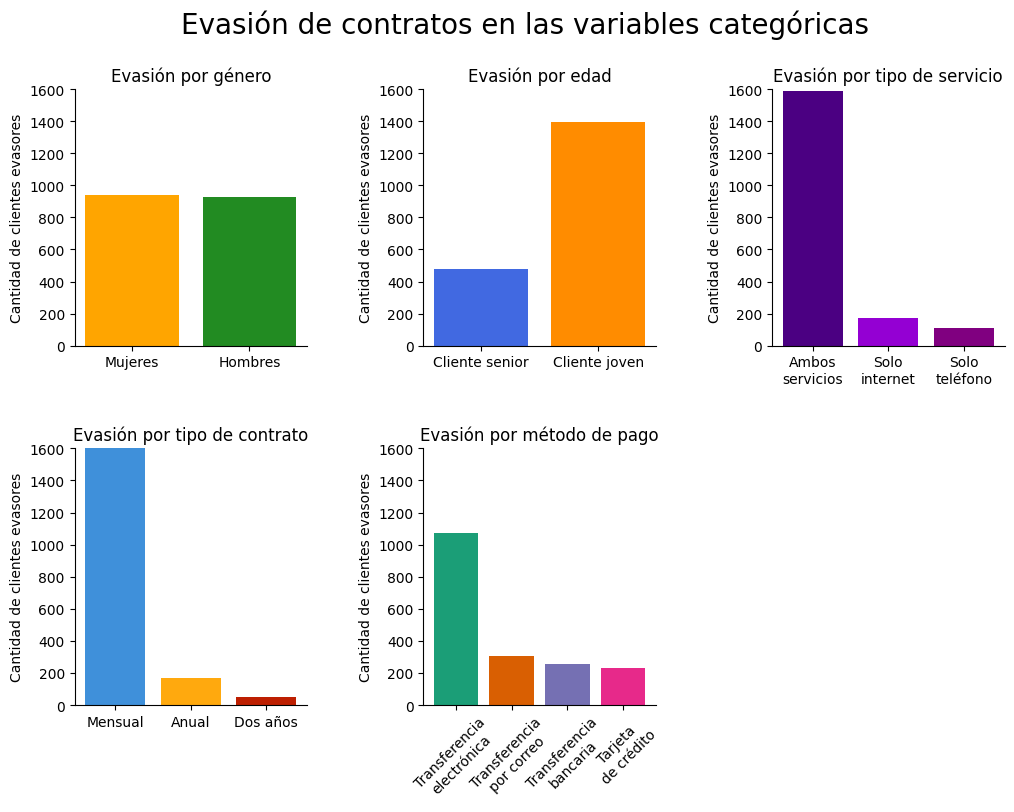

In [412]:
fig2, axs = plt.subplots(2,3, figsize=(12,8))
fig2.subplots_adjust(wspace=0.5, hspace=0.4)
fig2.suptitle('Evasión de contratos en las variables categóricas', fontsize=20)

for ax in axs.ravel():
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)

ymin=0
ymax=1600

#Gráfico 1
axs[0,0].bar(df_genero['Género'], df_genero['Cantidad'], color = ['orange','forestgreen'])
axs[0,0].set_title('Evasión por género')
axs[0,0].set_ylabel('Cantidad de clientes evasores')
axs[0,0].set_ylim(ymin,ymax)

#Gráfico 2
axs[0,1].bar(df_senior['Senior'], df_senior['Cantidad'], color = ['royalblue','darkorange'])
axs[0,1].set_title('Evasión por edad')
axs[0,1].set_ylabel('Cantidad de clientes evasores')
axs[0,1].set_ylim(ymin,ymax)

#Gráfico 3
servicios_labels = ['Ambos\nservicios', 'Solo\ninternet', 'Solo\nteléfono']
x_positions = [0, 1, 2]
axs[0,2].set_xticks(x_positions)
axs[0,2].set_xticklabels(servicios_labels)
axs[0,2].bar(df_servicios['Servicio'], df_servicios['Cantidad'], color = ['indigo','darkviolet','purple'])
axs[0,2].set_title('Evasión por tipo de servicio')
axs[0,2].set_ylabel('Cantidad de clientes evasores')
axs[0,2].set_ylim(ymin,ymax)

#Gráfico 4
contract_labels = ['Mensual', 'Anual', 'Dos años']
axs[1,0].set_xticks(x_positions)
axs[1,0].set_xticklabels(contract_labels)
axs[1,0].bar(df_contract['Contrato'], df_contract['Cantidad'], color =  plt.color_sequences['petroff10'])
axs[1,0].set_title('Evasión por tipo de contrato')
axs[1,0].set_ylabel('Cantidad de clientes evasores')
axs[1,0].set_ylim(ymin,ymax)

#Gráfico 5
payment_labels = ['Transferencia\nelectrónica', 'Transferencia\npor correo', 'Transferencia\nbancaria', 'Tarjeta\nde crédito']
x_position = [0, 1, 2, 3]
axs[1,1].set_xticks(x_position)
axs[1,1].set_xticklabels(payment_labels, rotation=45)
axs[1,1].bar(df_payment['Método de pago'], df_payment['Cantidad'], color = plt.color_sequences['Dark2'])
axs[1,1].set_title('Evasión por método de pago')
axs[1,1].set_ylabel('Cantidad de clientes evasores')
axs[1,1].set_ylim(ymin,ymax)

axs[1,2].spines['left'].set_visible(False)
axs[1,2].spines['bottom'].set_visible(False)
axs[1,2].set_xticklabels([])
axs[1,2].set_yticklabels([])
axs[1,2].set_xticks([])
axs[1,2].set_yticks([])

plt.show()

Evasión por variables no categóricas

In [413]:
no_evadidos = df_datos[df_datos['Churn'] == 0]
no_evadidos.head()

,customerID,Churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,2.00
5,0013-MHZWF,0,Female,0,0,1,9,1,0,DSL,...,0,1,1,1,Month-to-month,1,Credit card automatic,69.40,571.45,2.31
6,0013-SMEOE,0,Female,1,1,0,71,1,0,Fiber optic,...,1,1,1,1,Two year,1,Bank transfer automatic,109.70,7904.25,3.66
7,0014-BMAQU,0,Male,0,1,0,63,1,1,Fiber optic,...,0,1,0,0,Two year,1,Credit card automatic,84.65,5377.80,2.82


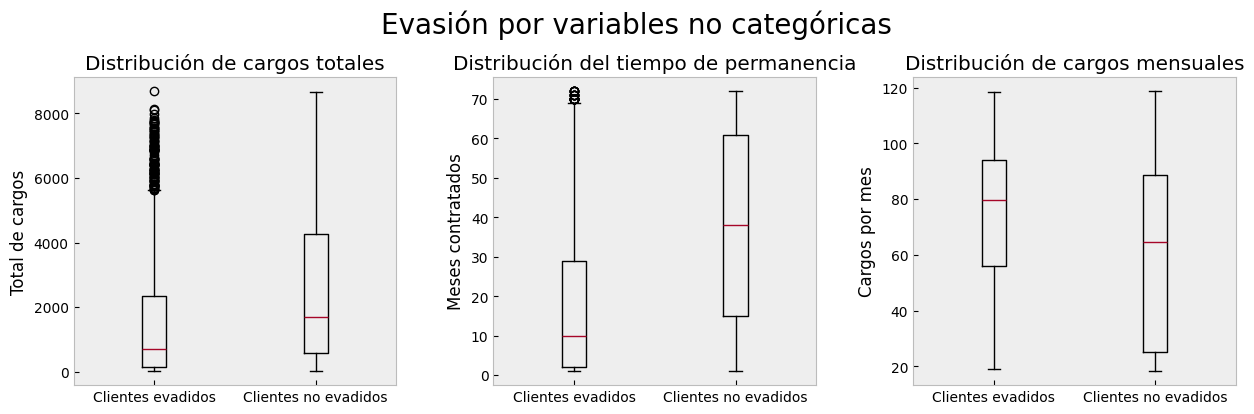

In [414]:
with plt.style.context('bmh'):
  fig3, axs = plt.subplots(1,3, figsize=(15,4))
  fig3.suptitle('Evasión por variables no categóricas', fontsize=20, y=1.05)
  fig3.subplots_adjust(wspace=0.3)

  for ax in axs.flat:
    ax.grid()

  pos = [1,2]

  axs[0].boxplot(evadidos['total_charges'], positions=[pos[0]])
  axs[0].boxplot(no_evadidos['total_charges'], positions=[pos[1]])
  axs[0].set_xticks(pos)
  axs[0].set_xticklabels(['Clientes evadidos', 'Clientes no evadidos'])
  axs[0].set_ylabel('Total de cargos')
  axs[0].set_title('Distribución de cargos totales')

  axs[1].boxplot(evadidos['tenure'], positions=[pos[0]])
  axs[1].boxplot(no_evadidos['tenure'], positions=[pos[1]])
  axs[1].set_xticks(pos)
  axs[1].set_xticklabels(['Clientes evadidos', 'Clientes no evadidos'])
  axs[1].set_ylabel('Meses contratados')
  axs[1].set_title('Distribución del tiempo de permanencia')

  axs[2].boxplot(evadidos['monthly_charges'], positions=[pos[0]])
  axs[2].boxplot(no_evadidos['monthly_charges'], positions=[pos[1]])
  axs[2].set_xticks(pos)
  axs[2].set_xticklabels(['Clientes evadidos', 'Clientes no evadidos'])
  axs[2].set_ylabel('Cargos por mes')
  axs[2].set_title('Distribución de cargos mensuales')

  plt.show()

##**Anexo Gráficos Recreados**

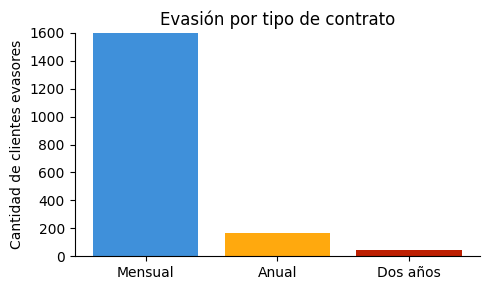

In [415]:
fig2a, ax_single = plt.subplots(figsize=(5, 3))
ax_single.spines['top'].set_visible(False)
ax_single.spines['right'].set_visible(False)

contract_labels = ['Mensual', 'Anual', 'Dos años']
x_positions = [0, 1, 2]
ymin=0
ymax=1600

ax_single.set_xticks(x_positions)
ax_single.set_xticklabels(contract_labels)
ax_single.bar(df_contract['Contrato'], df_contract['Cantidad'], color=plt.color_sequences['petroff10'])
ax_single.set_title('Evasión por tipo de contrato')
ax_single.set_ylabel('Cantidad de clientes evasores')
ax_single.set_ylim(ymin, ymax)
plt.tight_layout()
plt.show()

(0.0, 1600.0)

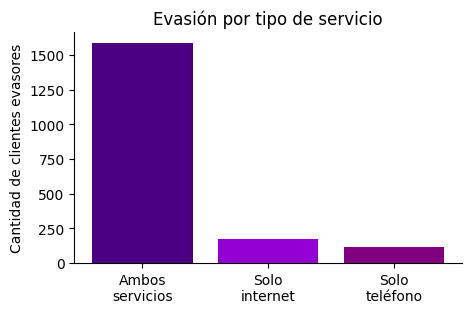

In [442]:
fig2b, ax = plt.subplots(figsize=(5, 3))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ymin=0
ymax=1600
servicios_labels = ['Ambos\nservicios', 'Solo\ninternet', 'Solo\nteléfono']
x_positions = [0, 1, 2]
ax.set_xticks(x_positions)
ax.set_xticklabels(servicios_labels)
ax.bar(df_servicios['Servicio'], df_servicios['Cantidad'], color = ['indigo','darkviolet','purple'])
ax.set_title('Evasión por tipo de servicio')
ax.set_ylabel('Cantidad de clientes evasores')
axs.set_ylim(ymin,ymax)

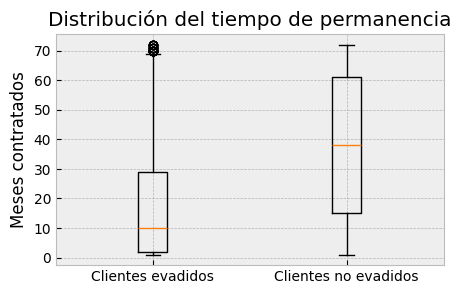

In [433]:

with plt.style.context('bmh'):
  fig3a, axs = plt.subplots( figsize=(5,3))
  ax.grid()

  axs.boxplot(evadidos['tenure'], positions=[pos[0]])
  axs.boxplot(no_evadidos['tenure'], positions=[pos[1]])
  axs.set_xticks(pos)
  axs.set_xticklabels(['Clientes evadidos', 'Clientes no evadidos'])
  axs.set_ylabel('Meses contratados')
  axs.set_title('Distribución del tiempo de permanencia')

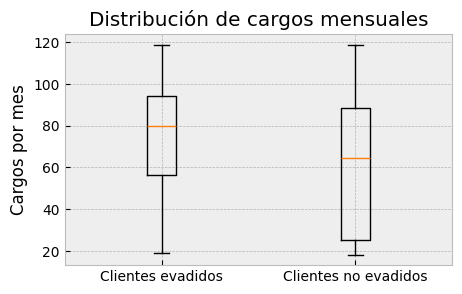

In [437]:
with plt.style.context('bmh'):
  fig3b, axs = plt.subplots( figsize=(5,3))
  ax.grid()

  axs.boxplot(evadidos['monthly_charges'], positions=[pos[0]])
  axs.boxplot(no_evadidos['monthly_charges'], positions=[pos[1]])
  axs.set_xticks(pos)
  axs.set_xticklabels(['Clientes evadidos', 'Clientes no evadidos'])
  axs.set_ylabel('Cargos por mes')
  axs.set_title('Distribución de cargos mensuales')

#📄Informe final

**Informe Ejecutivo**: Estrategias para Reducir la Pérdida de Clientes

**Resumen:** El análisis muestra que la tasa de cancelación es del 26.6%. Los clientes que se van tienen un perfil muy claro: **contratos mensuales, usan cheque electrónico y son relativamente nuevos**. Las siguientes estrategias están diseñadas para atacar estos puntos críticos de manera simple y efectiva.

**Estrategias Clave**

**1. Fidelizar con Contratos Más Largos**

Problema: Como se puede apreciar en el gráfico a continuación, el 88% de los clientes que cancelan tienen contrato mensual.

Solución: Ofrecer incentivos atractivos para que los clientes se cambien a contratos anuales o de dos años.

Implementación: Descuentos en la factura, meses gratis o mejoras en el servicio a cambio de firmar un contrato más largo.



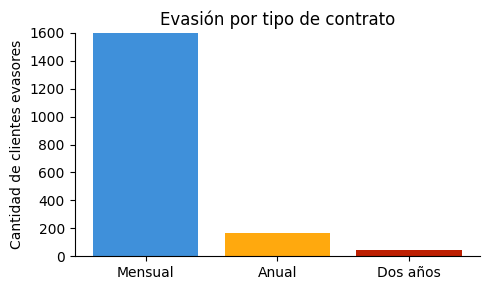

In [416]:
display(fig2a)

**2. Promover el Pago Automático**

Problema: Según la tabla que se muestra a continuación, el 57% de los clientes que cancelan pagan con cheque electrónico, un método propenso a olvidos y retrasos.

Solución: Motivar a los clientes a cambiar a débito automático (tarjeta de crédito o transferencia).

Implementación: Ofrecer un pequeño descuento mensual por activar el pago automático.



In [417]:
display(df_payment)

,Método de pago,Cantidad
Id,,
1,Electronic check,1071
2,Mailed check,308
3,Bank transfer automatic,258
4,Credit card automatic,232


**3. Acompañar a los Clientes Nuevos**

Problema: El riesgo de cancelación es más alto durante el primer año (la mitad de los que se van tienen menos de 10 meses de antigüedad). Con la gráfica siguiente, nos podemos apoyar visualmente de este dato.

Solución: Crear un programa de bienvenida y acompañamiento durante los primeros meses.

Implementación: Llamadas de bienvenida, correos con consejos útiles y una oferta especial de renovación antes de que cumplan el año.



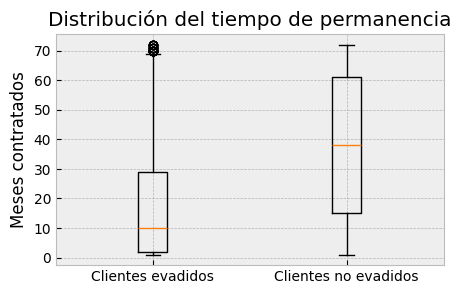

In [435]:
display(fig3a)

**4. Revisar el Precio de los Paquetes**

Problema: Los clientes que se van pagan, en promedio, una factura mensual más alta que los que se quedan. De la gráfica adjunta se puede evidenciar esta comparativa, de los clientes que se quedan versus los que se van y sus cargos por mes.

Solución: Asegurar que los precios de los paquetes (especialmente los que incluyen internet de fibra óptica) sean justos en comparación con la competencia.

Implementación: Investigar si los clientes que pagan más están teniendo problemas de calidad o servicio que justifiquen su decisión de irse.



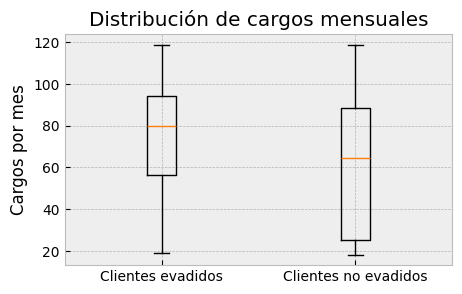

In [438]:
display(fig3b)

**5. Proteger a los Clientes con Más Servicios**

Problema: En la grafica siguiente, podemos visualizar que el 85% de las cancelaciones son de clientes que tienen contratados tanto el internet como el teléfono.

Solución: Crear un equipo especial de "retención" para atender a estos clientes de alto valor cuando pidan la baja.

Implementación: Este equipo debe tener la capacidad de ofrecer descuentos o mejoras para convencerlos de quedarse.

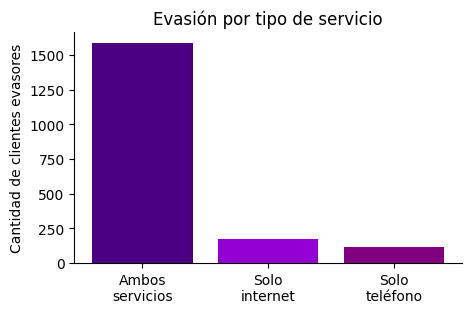

In [443]:
display(fig2b)

**En definitiva:** Para reducir las cancelaciones, debemos enfocarnos en convertir contratos mensuales en contratos a largo plazo, simplificar y automatizar los pagos, y cuidar especialmente a los clientes durante su primer año con nosotros.